In [1]:
import pandas as pd

file_path = 'base_anonimizada/df_fam_pes.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE
0,1,718.0,2,11,49,0,4,1,1,1,...,0.500000,0.0,0.0,0.000000,0,0,0.000000,0.0,0.500000,0.000000
1,2,1524.0,2,11,114,0,3,1,1,1,...,1.000000,0.0,0.0,0.333333,0,0,0.000000,0.0,0.000000,0.000000
2,3,100.0,2,11,155,0,1,1,1,2,...,1.000000,0.0,0.0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,4,152.0,2,11,601,0,9,1,1,1,...,0.250000,0.0,0.0,0.000000,0,0,0.125000,0.0,0.750000,0.000000
4,5,639.0,2,11,205,0,3,1,2,1,...,0.333333,0.0,0.0,0.000000,0,0,0.333333,0.0,0.333333,0.333333


In [2]:
# Quantidade total de NaN por coluna
nan_por_coluna = df.isna().sum().sort_values(ascending=False)

display(nan_por_coluna[nan_por_coluna > 0])

Series([], dtype: int64)

In [3]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [4]:
import numpy as np

# Definir condições
condicoes = [
    df['VL_RENDA_MEDIA_FAM'] <= 218,                      # 0 - pobreza
    (df['VL_RENDA_MEDIA_FAM'] > 218) & (df['VL_RENDA_MEDIA_FAM'] <= 759),  # 1 - baixa renda
    df['VL_RENDA_MEDIA_FAM'] > 759                       # 2 - acima de 1/2 salário mínimo
]

# Valores correspondentes
valores = [0, 1, 2]

# Criar a nova coluna
df['classe_renda'] = np.select(condicoes, valores)



In [5]:
df.groupby('classe_renda')['ID_FAM_ANON'].nunique()


classe_renda
0    1332272
1    3026181
2    5311569
Name: ID_FAM_ANON, dtype: int64

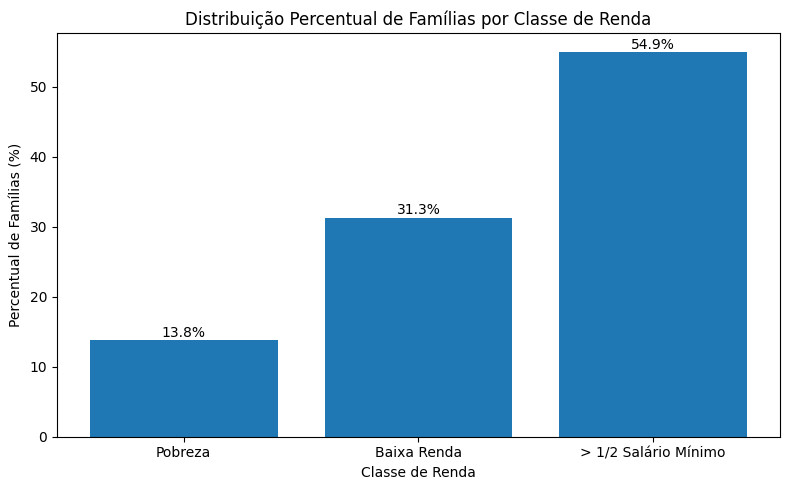

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Contar famílias únicas por classe de renda
familias_por_classe = (
    df.groupby('classe_renda')['ID_FAM_ANON']
      .nunique()
      .reset_index(name='qt_familias')
)

# 2) Calcular percentuais
total_familias = familias_por_classe['qt_familias'].sum()
familias_por_classe['percentual'] = (
    familias_por_classe['qt_familias'] / total_familias * 100
)

# 3) Criar gráfico
plt.figure(figsize=(8,5))
plt.bar(
    familias_por_classe['classe_renda'],
    familias_por_classe['percentual']
)

# Rótulos e formatação
plt.xlabel("Classe de Renda")
plt.ylabel("Percentual de Famílias (%)")
plt.title("Distribuição Percentual de Famílias por Classe de Renda")
plt.xticks([0,1,2], ["Pobreza", "Baixa Renda", "> 1/2 Salário Mínimo"])

# Mostrar valores no topo das barras
for i, v in enumerate(familias_por_classe['percentual']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()



In [7]:
df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,1,718.0,2,11,49,0,4,1,1,1,...,0.0,0.0,0.000000,0,0,0.000000,0.0,0.500000,0.000000,1
1,2,1524.0,2,11,114,0,3,1,1,1,...,0.0,0.0,0.333333,0,0,0.000000,0.0,0.000000,0.000000,2
2,3,100.0,2,11,155,0,1,1,1,2,...,0.0,0.0,0.000000,0,0,0.000000,0.0,0.000000,0.000000,0
3,4,152.0,2,11,601,0,9,1,1,1,...,0.0,0.0,0.000000,0,0,0.125000,0.0,0.750000,0.000000,0
4,5,639.0,2,11,205,0,3,1,2,1,...,0.0,0.0,0.000000,0,0,0.333333,0.0,0.333333,0.333333,1


In [8]:
df.shape

(9670022, 52)

In [9]:
import pandas as pd
import numpy as np

# Tamanho total desejado para cada amostra
N = 1_000_000
SEED = 42  # para tornar a amostragem reprodutível

# -------------------------------------------------------------------
# 1) AMOSTRA BALANCEADA POR classe_renda
# -------------------------------------------------------------------

# Quantidade de famílias por classe
vc = df['classe_renda'].value_counts().sort_index()
print("Distribuição original de classe_renda:")
print(vc)

# Número (aproximado) por classe para balancear
n_por_classe_bal = N // 3  

# Verifica se cada classe tem pelo menos n_por_classe_bal linhas
if (vc < n_por_classe_bal).any():
    raise ValueError(
        f"Alguma classe não tem linhas suficientes para amostragem balanceada de {n_por_classe_bal} por classe.\n"
        f"Counts:\n{vc}"
    )

# Amostra balanceada
amostras_bal = []
for i, classe in enumerate(sorted(df['classe_renda'].unique())):
    amostra_classe = df[df['classe_renda'] == classe].sample(
        n=n_por_classe_bal,
        random_state=SEED + i
    )
    amostras_bal.append(amostra_classe)

df_bal = pd.concat(amostras_bal, axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nDistribuição da amostra balanceada:")
print(df_bal['classe_renda'].value_counts().sort_index())
print(df_bal.shape)

Distribuição original de classe_renda:
classe_renda
0    1332272
1    3026181
2    5311569
Name: count, dtype: int64

Distribuição da amostra balanceada:
classe_renda
0    333333
1    333333
2    333333
Name: count, dtype: int64
(999999, 52)


In [10]:
df_bal.to_csv("df_bal.csv", index=False, encoding="utf-8")

In [11]:
import pandas as pd
import numpy as np

# Tamanho total desejado para cada amostra
N = 1_000_000
SEED = 42  # para tornar a amostragem reprodutível


# -------------------------------------------------------------------
# 2) AMOSTRA PROPORCIONAL À DISTRIBUIÇÃO ORIGINAL
# -------------------------------------------------------------------

vc = df['classe_renda'].value_counts().sort_index()
proporcoes = vc / vc.sum()

# Número de casos por classe (aprox), garantindo soma = N
n_por_classe_prop = (proporcoes * N).round().astype(int)

# Ajuste fino se a soma não der exatamente N (por causa de arredondamento)
diferenca = N - n_por_classe_prop.sum()
if diferenca != 0:
    # Ordena classes pela contagem original (das mais frequentes para as menos)
    ordem_ajuste = vc.sort_values(ascending=False).index.tolist()
    idx = 0
    passo = 1 if diferenca > 0 else -1
    for _ in range(abs(diferenca)):
        classe_ajustar = ordem_ajuste[idx % len(ordem_ajuste)]
        n_por_classe_prop[classe_ajustar] += passo
        idx += 1

print("\nTamanho por classe na amostra proporcional:")
print(n_por_classe_prop, " (soma:", n_por_classe_prop.sum(), ")")

# Amostragem proporcional
amostras_prop = []
for i, (classe, n_cls) in enumerate(n_por_classe_prop.items()):
    amostra_classe = df[df['classe_renda'] == classe].sample(
        n=n_cls,
        random_state=SEED + 100 + i
    )
    amostras_prop.append(amostra_classe)

df_prop = pd.concat(amostras_prop, axis=0).sample(frac=1, random_state=SEED+999).reset_index(drop=True)

print("\nDistribuição da amostra proporcional:")
print(df_prop['classe_renda'].value_counts().sort_index())
print(df_prop.shape)



Tamanho por classe na amostra proporcional:
classe_renda
0    137773
1    312945
2    549282
Name: count, dtype: int64  (soma: 1000000 )

Distribuição da amostra proporcional:
classe_renda
0    137773
1    312945
2    549282
Name: count, dtype: int64
(1000000, 52)


In [12]:
# Salvar amostra proporcional
df_prop.to_csv("df_prop.csv", index=False, encoding="utf-8")